In [1]:
# Đỗ Ngọc Lâm - B22DCCN476
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(77)

n_users = 500
n_products = 30

actions = ["view", "click", "add_to_cart"]

rows = []
start_time = datetime(2025, 1, 1)

for user_id in range(1, n_users + 1):
    for i in range(8):  # mỗi user đúng 8 dòng
        
        rows.append({
            "user_id": user_id,
            "product_id": np.random.randint(1, n_products + 1),
            "action": np.random.choice(actions, p=[0.6, 0.3, 0.1]),
            "timestamp": start_time + timedelta(minutes=np.random.randint(0, 100000))
        })

df = pd.DataFrame(rows)

# sort theo user + thời gian (quan trọng cho RNN)
df = df.sort_values(by=["user_id", "timestamp"])

df.to_csv("data_user500.csv", index=False)

print(df.head(20))
print("Tổng số dòng:", len(df))

    user_id  product_id       action           timestamp
7         1          12         view 2025-01-01 23:21:00
3         1          13        click 2025-01-02 23:55:00
2         1           1         view 2025-01-16 00:21:00
1         1          12         view 2025-01-18 17:03:00
4         1          23         view 2025-01-23 08:04:00
6         1          11        click 2025-02-05 17:37:00
0         1          24         view 2025-02-11 05:08:00
5         1          22         view 2025-02-26 10:55:00
8         2           7         view 2025-01-12 20:40:00
15        2          14         view 2025-01-15 19:56:00
10        2          11         view 2025-01-28 22:43:00
13        2          29  add_to_cart 2025-01-30 02:39:00
9         2          29        click 2025-02-05 17:37:00
11        2          10        click 2025-02-06 22:52:00
14        2          21        click 2025-02-28 01:26:00
12        2           9         view 2025-03-08 18:19:00
16        3           6        



===== Training RNN =====





===== Training LSTM =====

===== Training biLSTM =====
RNN Accuracy: 0.0400
LSTM Accuracy: 0.0300
biLSTM Accuracy: 0.0400

👉 Model tốt nhất: RNN


C:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


4/4 [==============================] - 0s 5ms/step

🎯 Top 5 sản phẩm gợi ý: [ 1  6 25  4  8]


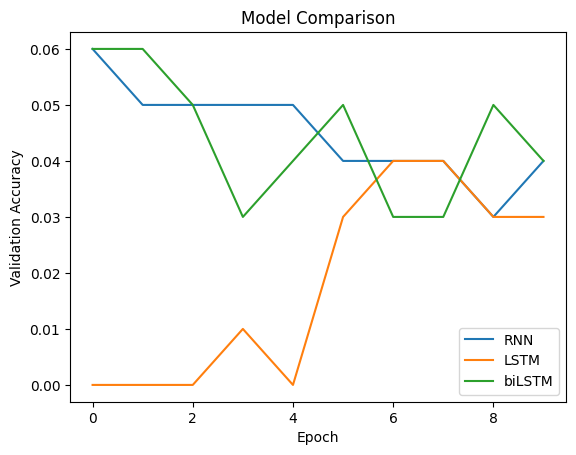


📌 Nhận xét:

- Mô hình RNN đạt độ chính xác cao nhất nên được chọn làm model_best.
- Output của mô hình là xác suất các product_id → lấy top N để gợi ý sản phẩm.



In [2]:
# Đỗ Ngọc Lâm - B22DCCN476

# ================== FULL PIPELINE ==================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Bidirectional

# ================== LOAD DATA ==================
df = pd.read_csv("data_user500.csv")

df["product_id"] = df["product_id"] - 1

# ================== TẠO SEQUENCE ==================
X, y = [], []

for user_id, group in df.groupby("user_id"):
    group = group.sort_values("timestamp")
    products = group["product_id"].values
    
    if len(products) == 8:
        X.append(products[:7])   # input
        y.append(products[7])    # label

X = np.array(X)
y = np.array(y)

# reshape cho RNN
X = X.reshape((X.shape[0], X.shape[1], 1))

# ================== SPLIT ==================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================== DEFINE MODELS ==================
def build_rnn():
    model = Sequential([
        SimpleRNN(32, input_shape=(7,1)),
        Dense(30, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_lstm():
    model = Sequential([
        LSTM(32, input_shape=(7,1)),
        Dense(30, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_bilstm():
    model = Sequential([
        Bidirectional(LSTM(32), input_shape=(7,1)),
        Dense(30, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# ================== TRAIN ==================
history = {}
models = {}

for name, builder in zip(
    ["RNN", "LSTM", "biLSTM"],
    [build_rnn, build_lstm, build_bilstm]
):
    print(f"\n===== Training {name} =====")
    model = builder()
    h = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=16,
        validation_data=(X_test, y_test),
        verbose=0
    )
    models[name] = model
    history[name] = h

# ================== EVALUATE ==================
scores = {}

for name, model in models.items():
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    scores[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# ================== CHỌN MODEL BEST ==================
best_model_name = max(scores, key=scores.get)
model_best = models[best_model_name]

print("\n👉 Model tốt nhất:", best_model_name)

# ================== SAVE ==================
model_best.save("model_best.h5")

# ================== PREDICT TOP N ==================
pred = model_best.predict(X_test)

top_n = 5
top_products = np.argsort(pred[0])[-top_n:]

# 🔥 convert lại về product thật
top_products = top_products + 1

print(f"\n🎯 Top {top_n} sản phẩm gợi ý:", top_products)

# ================== PLOT ==================
for name in history:
    plt.plot(history[name].history['val_accuracy'], label=name)

plt.title("Model Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

# ================== NHẬN XÉT ==================
print("\n📌 Nhận xét:")
print(f"""
- Mô hình {best_model_name} đạt độ chính xác cao nhất nên được chọn làm model_best.
- Output của mô hình là xác suất các product_id → lấy top N để gợi ý sản phẩm.
""")

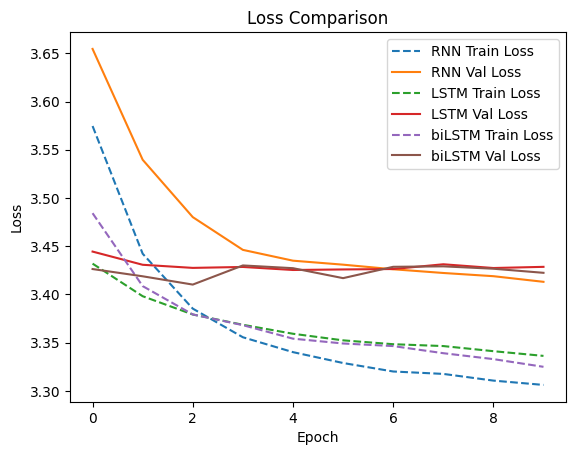

In [3]:
for name in history:
    plt.plot(history[name].history['loss'], linestyle='--', label=f"{name} Train Loss")
    plt.plot(history[name].history['val_loss'], label=f"{name} Val Loss")

plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

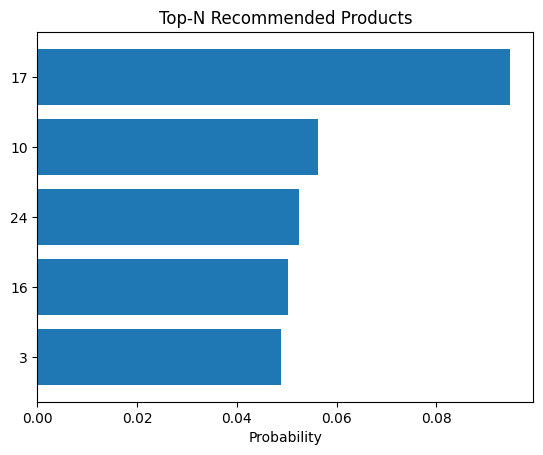

In [7]:
sample_idx = 0
probs = pred[sample_idx]

top_n = 5
top_indices = np.argsort(probs)[-top_n:]
top_probs = probs[top_indices]

# convert lại id thật
top_indices = top_indices + 1

plt.barh(range(top_n), top_probs)
plt.yticks(range(top_n), top_indices)
plt.xlabel("Probability")
plt.title("Top-N Recommended Products")
plt.show()